# Trabajo Práctico — 1C 2026
## Laboratorio de Métodos Cuantitativos · FCE UBA

**Dataset:** Estadísticas Vitales — Nacidos Vivos 2024  
**Fuente:** Dirección de Estadística e Información en Salud (DEIS), Ministerio de Salud de la Nación  
**Pregunta de investigación:** ¿Existe relación entre el nivel educativo de la madre y la natalidad adolescente por provincia?

---
## Parte 3.1 — Carga y exploración inicial

Se carga el dataset en un DataFrame de pandas y se realiza una exploración inicial para comprender su estructura, cobertura y calidad. El dataset proviene de las estadísticas vitales publicadas por el Ministerio de Salud de la Nación (DEIS) y contiene registros agregados de nacidos vivos en la Argentina durante 2024, con variables sociodemográficas de la madre.

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import sympy as sp
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')

df = pd.read_csv('/datos_sobre_nacidos_vivos_2024.csv', sep=';')

print('=== Primeras filas ===')
df.head()

=== Primeras filas ===


,PROVRES,TIPPARTO,SEXO,IMEDAD,ITIEMGEST,IMINSTRUC,IPESONAC,CUENTA
0,2,1,1,1.Menor de 15,6.37 a 41,3.Primaria/C. EGB Completa,4.1500 a 1999,1
1,2,1,1,1.Menor de 15,6.37 a 41,5.Secundaria/Polimodal Completa,8.De 3500 y más,1
2,2,1,1,2.15 a 19,3.24 a 27,4.Secundaria/Polimodal Incompleta,3.1000 a 1499,1
3,2,1,1,2.15 a 19,5.32 a 36,3.Primaria/C. EGB Completa,6.2500 a 2999,1
4,2,1,1,2.15 a 19,5.32 a 36,4.Secundaria/Polimodal Incompleta,5.2000 a 2499,3


In [53]:
print('=== Últimas filas ===')
df.tail()

=== Últimas filas ===


,PROVRES,TIPPARTO,SEXO,IMEDAD,ITIEMGEST,IMINSTRUC,IPESONAC,CUENTA
21961,99,9,2,8.De 45 y más,6.37 a 41,8.Sin especificar,6.2500 a 2999,3
21962,99,9,2,9.Sin especificar,6.37 a 41,8.Sin especificar,7.3000 a 3499,8
21963,99,9,2,9.Sin especificar,6.37 a 41,8.Sin especificar,8.De 3500 y más,3
21964,99,9,2,9.Sin especificar,8.Sin especificar,8.Sin especificar,9.Sin especificar,8
21965,99,9,9,9.Sin especificar,8.Sin especificar,8.Sin especificar,9.Sin especificar,4


### Estructura del dataset

A continuación se describe la dimensión, los tipos de dato y la cobertura del archivo. El dataset utiliza una codificación en intervalos (variables categóricas ordinales) que resume combinaciones de características, con la columna `CUENTA` indicando la cantidad de nacidos vivos para cada combinación. Esta estructura de datos agregados —y no registros individuales— es una decisión de diseño de la DEIS para preservar la confidencialidad de los datos, según la Ley 17.622.

In [54]:
print('--- Dimensiones ---')
print(f'Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}')

print('\n--- Tipos de dato ---')
print(df.dtypes)

print('\n--- Descripción de variables ---')
descripcion = {
    'PROVRES':   'Código de jurisdicción de residencia habitual de la madre',
    'TIPPARTO':  'Tipo de parto (Simple / Múltiple)',
    'SEXO':      'Sexo del nacido vivo',
    'IMEDAD':    'Intervalo de edad de la madre',
    'ITIEMGEST': 'Intervalo de tiempo de gestación (semanas)',
    'IMINSTRUC': 'Intervalo de máximo nivel de instrucción de la madre',
    'IPESONAC':  'Intervalo de peso al nacer (gramos)',
    'CUENTA':    'Cantidad de nacidos vivos para la combinación'
}
for col, desc in descripcion.items():
    print(f'  {col}: {desc}')

--- Dimensiones ---
Filas: 21,966  |  Columnas: 8

--- Tipos de dato ---
PROVRES       int64
TIPPARTO      int64
SEXO          int64
IMEDAD       object
ITIEMGEST    object
IMINSTRUC    object
IPESONAC     object
CUENTA        int64
dtype: object

--- Descripción de variables ---
  PROVRES: Código de jurisdicción de residencia habitual de la madre
  TIPPARTO: Tipo de parto (Simple / Múltiple)
  SEXO: Sexo del nacido vivo
  IMEDAD: Intervalo de edad de la madre
  ITIEMGEST: Intervalo de tiempo de gestación (semanas)
  IMINSTRUC: Intervalo de máximo nivel de instrucción de la madre
  IPESONAC: Intervalo de peso al nacer (gramos)
  CUENTA: Cantidad de nacidos vivos para la combinación


In [55]:
print('--- Análisis de calidad ---')
print(f'Valores nulos por columna:')
print(df.isnull().sum())
print(f'\nRegistros duplicados: {df.duplicated().sum()}')
print(f'\nEstadísticas descriptivas de CUENTA (nacidos vivos por combinación):')
print(df['CUENTA'].describe().round(2))

--- Análisis de calidad ---
Valores nulos por columna:
PROVRES      0
TIPPARTO     0
SEXO         0
IMEDAD       0
ITIEMGEST    0
IMINSTRUC    0
IPESONAC     0
CUENTA       0
dtype: int64

Registros duplicados: 0

Estadísticas descriptivas de CUENTA (nacidos vivos por combinación):
count    21966.00
mean        18.81
std         98.79
min          1.00
25%          1.00
50%          2.00
75%          7.00
max       4000.00
Name: CUENTA, dtype: float64


**Hallazgos de calidad:** El dataset no presenta valores nulos ni duplicados. La columna `CUENTA` tiene una media de 18.8 nacidos vivos por combinación, con alta variabilidad (desvío estándar: 98.8) y un máximo de 4.000, lo que refleja la diferencia de tamaño entre provincias grandes (Buenos Aires) y pequeñas (Tierra del Fuego). Existen registros con categorías 'Sin especificar' en las variables de edad, educación y provincia que serán excluidos en la etapa de transformación.

In [56]:
print('Valores únicos por variable categórica:')
for col in ['IMEDAD', 'IMINSTRUC']:
    vals = sorted(df[col].unique())
    print(f'\n{col}: {vals}')

Valores únicos por variable categórica:

IMEDAD: ['1.Menor de 15', '2.15 a 19', '3.20 a 24', '4.25 a 29', '5.30 a 34', '6.35 a 39', '7.40 a 44', '8.De 45 y más', '9.Sin especificar']

IMINSTRUC: ['1.Sin instrucción', '2.Primaria/C. EGB Incompleta', '3.Primaria/C. EGB Completa', '4.Secundaria/Polimodal Incompleta', '5.Secundaria/Polimodal Completa', '6.Terciaria/Universitaria Incompleta', '7.Terciaria/Universitaria Completa', '8.Sin especificar']


---
## Parte 3.2 — Pregunta de investigación

**a) ¿Cuál es la pregunta?**

> ¿Existe relación entre el nivel educativo de la madre y la natalidad adolescente por provincia en Argentina durante 2024?

La pregunta está acotada a un año (2024), a una unidad territorial (provincia) y a dos variables disponibles en el dataset: el nivel educativo de la madre (`IMINSTRUC`) y el grupo etario de la madre (`IMEDAD`, con foco en menores de 20 años). Es directamente respondible con los datos disponibles.

**b) ¿Por qué vale la pena responderla?**

La natalidad adolescente es un fenómeno con consecuencias documentadas en la salud materna, la trayectoria educativa y la transmisión intergeneracional de la pobreza. En Argentina, la tasa varía notablemente entre provincias, lo que sugiere que factores estructurales, entre ellos el nivel educativo, pueden estar asociados. Comprender esta relación a nivel provincial permite identificar regiones prioritarias para políticas públicas de salud reproductiva y educación.

**c) ¿Qué respuesta encontraron?** *(se completa al finalizar el análisis)*

Sí existe una relación positiva moderada-alta (r de Pearson = 0.71) entre la proporción de madres con bajo nivel educativo y el porcentaje de natalidad adolescente por provincia. Las provincias del NEA y NOA —Formosa, Misiones, Chaco, Santiago del Estero— concentran los valores más elevados en ambas variables. A nivel nacional, el grupo de madres con secundaria incompleta tiene la mayor proporción de natalidad adolescente (20,2%), mientras que entre las madres con universitaria completa ese porcentaje cae a 0,1%. La elasticidad arco calculada entre los extremos educativos es de −1.31, indicando que la natalidad adolescente cae más que proporcionalmente a medida que aumenta el nivel educativo.

---
## Parte 3.3 — Transformaciones y resumen estadístico

### Transformación 1: Mapeo de códigos y creación de variables derivadas

Los códigos numéricos de provincia y las etiquetas de educación y edad se transforman en variables legibles. Adicionalmente, se crea la variable binaria `adolescente` (True si la madre tiene menos de 20 años) y la variable `bajo_nivel_edu` para clasificar a las madres con primaria completa o menos. Esta decisión sigue los estándares habituales en estudios de fecundidad adolescente en Argentina.

In [57]:
# Transformación 1: mapeo de provincias y variables derivadas

prov_map = {
    2: 'CABA', 6: 'Buenos Aires', 10: 'Catamarca', 14: 'Córdoba',
    18: 'Corrientes', 22: 'Chaco', 26: 'Chubut', 30: 'Entre Ríos',
    34: 'Formosa', 38: 'Jujuy', 42: 'La Pampa', 46: 'La Rioja',
    50: 'Mendoza', 54: 'Misiones', 58: 'Neuquén', 62: 'Río Negro',
    66: 'Salta', 70: 'San Juan', 74: 'San Luis', 78: 'Santa Cruz',
    82: 'Santa Fe', 86: 'Santiago del Estero', 90: 'Tucumán',
    94: 'Tierra del Fuego'
}

df['provincia'] = df['PROVRES'].map(prov_map)

# Variable binaria: madre adolescente (< 20 años)
df['adolescente'] = df['IMEDAD'].isin(['1.Menor de 15', '2.15 a 19'])

# Variable binaria: bajo nivel educativo (sin instrucción o primaria)
bajo_edu_cats = [
    '1.Sin instrucción',
    '2.Primaria/C. EGB Incompleta',
    '3.Primaria/C. EGB Completa'
]
df['bajo_nivel_edu'] = df['IMINSTRUC'].isin(bajo_edu_cats)

print('Variables derivadas creadas: provincia, adolescente, bajo_nivel_edu')
df[['PROVRES','provincia','IMEDAD','adolescente','IMINSTRUC','bajo_nivel_edu']].head(8)

Variables derivadas creadas: provincia, adolescente, bajo_nivel_edu


,PROVRES,provincia,IMEDAD,adolescente,IMINSTRUC,bajo_nivel_edu
0,2,CABA,1.Menor de 15,True,3.Primaria/C. EGB Completa,True
1,2,CABA,1.Menor de 15,True,5.Secundaria/Polimodal Completa,False
2,2,CABA,2.15 a 19,True,4.Secundaria/Polimodal Incompleta,False
3,2,CABA,2.15 a 19,True,3.Primaria/C. EGB Completa,True
4,2,CABA,2.15 a 19,True,4.Secundaria/Polimodal Incompleta,False
5,2,CABA,2.15 a 19,True,4.Secundaria/Polimodal Incompleta,False
6,2,CABA,2.15 a 19,True,8.Sin especificar,False
7,2,CABA,2.15 a 19,True,4.Secundaria/Polimodal Incompleta,False


### Transformación 2: Filtrado de registros con categorías 'Sin especificar'

Se eliminan los registros con valores 'Sin especificar' en las variables de interés (edad, educación) y los nacidos de madres residentes fuera del país o sin provincia especificada. Estos registros representan información incompleta que no permite responder la pregunta de investigación. Se documentan las filas eliminadas para trazabilidad.

In [58]:
# Transformación 2: filtrado

n_original = len(df)

df_clean = df[
    (~df['PROVRES'].isin([98, 99])) &          # excluir 'Otro país' y 'Sin especificar'
    (df['IMINSTRUC'] != '8.Sin especificar') &
    (df['IMEDAD'] != '9.Sin especificar') &
    (df['provincia'].notna())
].copy()

n_clean = len(df_clean)
print(f'Registros originales:  {n_original:,}')
print(f'Registros eliminados:  {n_original - n_clean:,} ({(n_original-n_clean)/n_original*100:.1f}%)')
print(f'Registros para análisis: {n_clean:,}')

# Nacidos vivos totales representados
nv_total = df_clean['CUENTA'].sum()
print(f'\nNacidos vivos totales representados: {nv_total:,}')

Registros originales:  21,966
Registros eliminados:  2,469 (11.2%)
Registros para análisis: 19,497

Nacidos vivos totales representados: 383,128


### Resumen estadístico agrupado 1: Nacidos vivos y proporción adolescente por provincia

Se calcula para cada provincia el total de nacidos vivos, el número de nacidos de madres adolescentes, y la proporción sobre el total. Este indicador es la variable dependiente central del análisis.

In [59]:
# Groupby 1: natalidad adolescente por provincia

total_prov = df_clean.groupby('provincia')['CUENTA'].sum().rename('total_nacidos')
adol_prov  = df_clean[df_clean['adolescente']].groupby('provincia')['CUENTA'].sum().rename('nacidos_adol')

tabla_prov = pd.concat([total_prov, adol_prov], axis=1).fillna(0)
tabla_prov['%_adolescente'] = (tabla_prov['nacidos_adol'] / tabla_prov['total_nacidos'] * 100).round(2)
tabla_prov = tabla_prov.sort_values('%_adolescente', ascending=False)

print('=== Natalidad adolescente por provincia (ordenado de mayor a menor) ===')
tabla_prov.style.format({'total_nacidos': '{:,.0f}', 'nacidos_adol': '{:,.0f}', '%_adolescente': '{:.2f}%'})

=== Natalidad adolescente por provincia (ordenado de mayor a menor) ===


,total_nacidos,nacidos_adol,%_adolescente
provincia,,,
Formosa,"4,899",791,16.15%
Misiones,"15,314","1,967",12.84%
Chaco,"13,996","1,713",12.24%
Santiago del Estero,"11,380","1,286",11.30%
Salta,"14,174","1,573",11.10%
San Juan,"8,693",955,10.99%
Corrientes,"9,506","1,003",10.55%
Entre Ríos,"12,496","1,119",8.95%
Santa Fe,"33,393","2,952",8.84%


**Interpretación:** Formosa (16.15%), Misiones (12.84%) y Chaco (12.24%) encabezan el ranking de natalidad adolescente, mientras que CABA (2.66%) y Tierra del Fuego (3.92%) presentan los valores más bajos. La diferencia de casi 14 puntos porcentuales entre el extremo superior e inferior del ranking refleja una marcada heterogeneidad territorial en Argentina.

### Resumen estadístico agrupado 2: Distribución del nivel educativo según grupo etario (nacional)

Se calcula, para cada nivel educativo, la proporción de nacidos vivos cuya madre es adolescente. Este resumen permite identificar en qué nivel educativo la natalidad adolescente es más frecuente.

In [60]:
# Groupby 2: distribución educativa por grupo etario

edu_grupo = df_clean.groupby(['IMINSTRUC', 'adolescente'])['CUENTA'].sum().unstack(fill_value=0)
edu_grupo.columns = ['No adolescente', 'Adolescente']
edu_grupo['Total'] = edu_grupo.sum(axis=1)
edu_grupo['% Natalidad adolescente'] = (edu_grupo['Adolescente'] / edu_grupo['Total'] * 100).round(2)

# Etiquetas cortas para visualización
etiquetas = {
    '1.Sin instrucción': 'Sin instrucción',
    '2.Primaria/C. EGB Incompleta': 'Primaria incompleta',
    '3.Primaria/C. EGB Completa': 'Primaria completa',
    '4.Secundaria/Polimodal Incompleta': 'Secundaria incompleta',
    '5.Secundaria/Polimodal Completa': 'Secundaria completa',
    '6.Terciaria/Universitaria Incompleta': 'Terciaria/Univ. incompleta',
    '7.Terciaria/Universitaria Completa': 'Terciaria/Univ. completa'
}
edu_grupo.index = [etiquetas.get(i, i) for i in edu_grupo.index]

print('=== % de natalidad adolescente por nivel educativo de la madre (nacional) ===')
edu_grupo.style.format({'No adolescente': '{:,.0f}', 'Adolescente': '{:,.0f}',
                         'Total': '{:,.0f}', '% Natalidad adolescente': '{:.2f}%'})

=== % de natalidad adolescente por nivel educativo de la madre (nacional) ===


,No adolescente,Adolescente,Total,% Natalidad adolescente
Sin instrucción,729,89,818,10.88%
Primaria incompleta,"6,995","1,079","8,074",13.36%
Primaria completa,"37,277","4,262","41,539",10.26%
Secundaria incompleta,"75,884","19,202","95,086",20.19%
Secundaria completa,"143,737","8,154","151,891",5.37%
Terciaria/Univ. incompleta,"24,060",546,"24,606",2.22%
Terciaria/Univ. completa,"61,048",66,"61,114",0.11%


**Interpretación:** La relación es clara y monótona: a mayor nivel educativo, menor proporción de natalidad adolescente. El caso extremo es el de secundaria incompleta (20.2%), que concentra la mayor parte de las madres adolescentes —probablemente porque el embarazo interrumpe la trayectoria escolar justo en ese nivel. En el extremo opuesto, solo el 0.11% de los nacidos vivos de madres con universitaria completa corresponde a adolescentes.

---
## Parte 3.4 — Análisis gráfico

### Gráfico 1: Distribución de natalidad adolescente por provincia (barras horizontales)

Se visualiza el porcentaje de nacidos vivos de madres adolescentes para cada provincia, ordenado de mayor a menor. Este gráfico permite identificar de manera inmediata las provincias con mayor y menor natalidad adolescente.

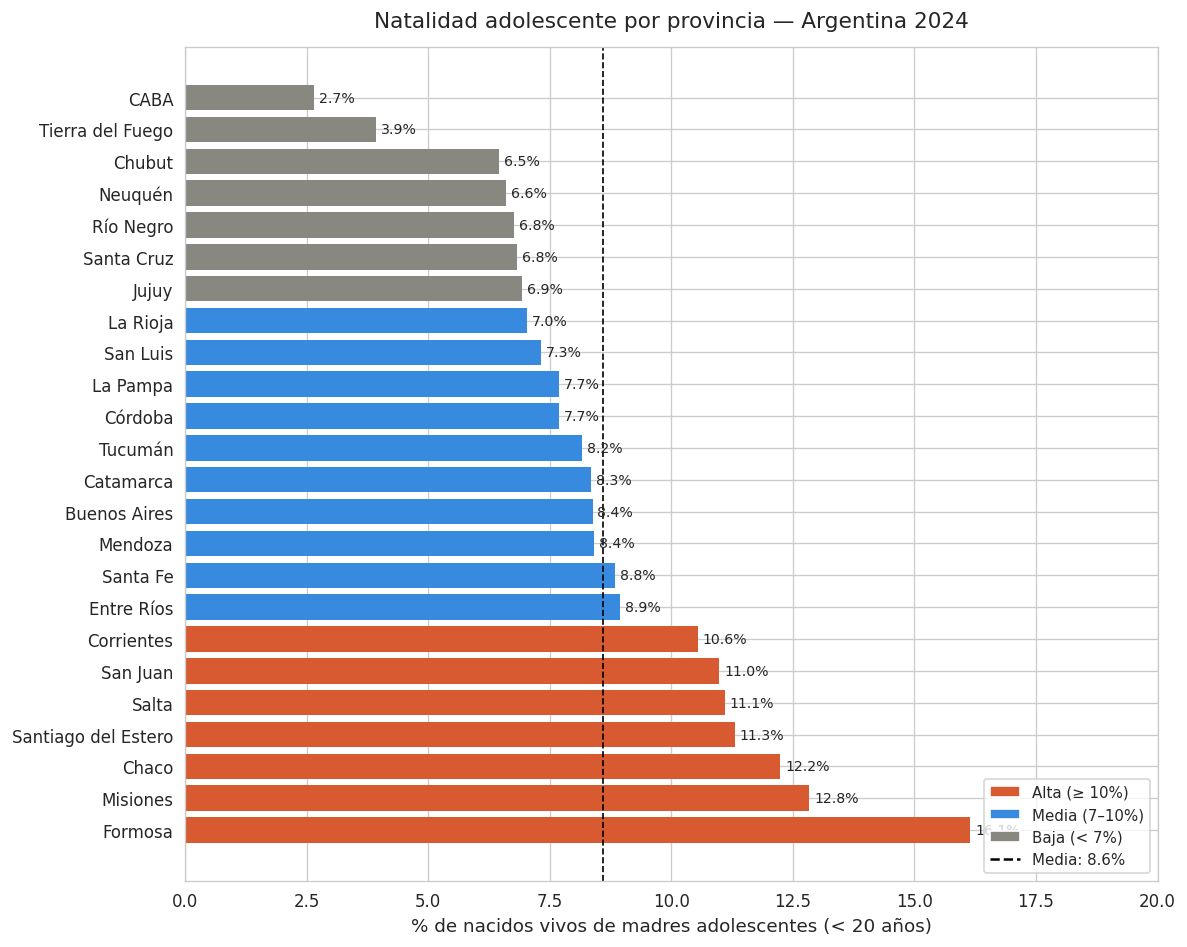

In [61]:
fig, ax = plt.subplots(figsize=(10, 8))

colores = ['#D85A30' if v >= 10 else '#378ADD' if v >= 7 else '#888780'
           for v in tabla_prov['%_adolescente']]

bars = ax.barh(tabla_prov.index, tabla_prov['%_adolescente'], color=colores, edgecolor='none')

for bar, val in zip(bars, tabla_prov['%_adolescente']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8.5)

ax.set_xlabel('% de nacidos vivos de madres adolescentes (< 20 años)', fontsize=11)
ax.set_title('Natalidad adolescente por provincia — Argentina 2024', fontsize=13, pad=12)
ax.axvline(tabla_prov['%_adolescente'].mean(), color='black', linestyle='--',
           linewidth=1, label=f"Media nacional: {tabla_prov['%_adolescente'].mean():.1f}%")
ax.legend(fontsize=9)
ax.set_xlim(0, 20)

# Leyenda de colores
from matplotlib.patches import Patch
leyenda = [
    Patch(facecolor='#D85A30', label='Alta (≥ 10%)'),
    Patch(facecolor='#378ADD', label='Media (7–10%)'),
    Patch(facecolor='#888780', label='Baja (< 7%)')
]
ax.legend(handles=leyenda + [plt.Line2D([0],[0], color='black', linestyle='--',
          label=f"Media: {tabla_prov['%_adolescente'].mean():.1f}%")],
          fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('grafico1_natalidad_adolescente_por_provincia.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretación:** Las provincias del NEA (Formosa, Misiones, Chaco, Corrientes) y del NOA (Santiago del Estero, Salta) superan ampliamente la media nacional. CABA y Tierra del Fuego son los únicos casos notoriamente por debajo del promedio. La línea punteada muestra la media nacional ponderada (aproximadamente 8.1%), que sirve como umbral de referencia para clasificar provincias.

### Gráfico 2: % de natalidad adolescente por nivel educativo de la madre (barras)

Se muestra cómo varía la proporción de natalidad adolescente a lo largo de los distintos niveles educativos de la madre a nivel nacional.

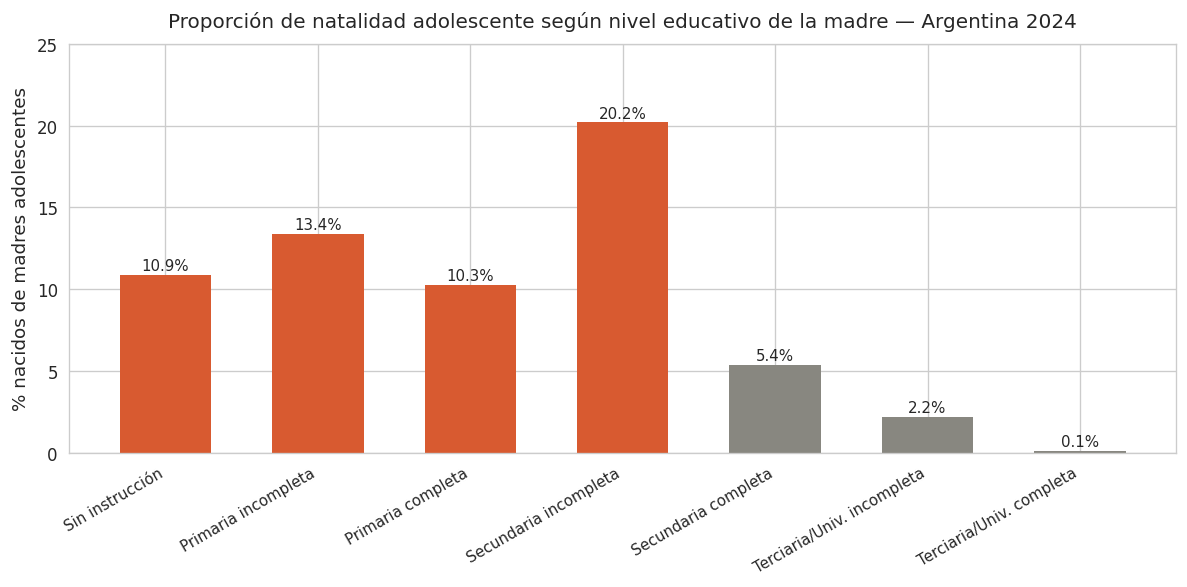

In [62]:
fig, ax = plt.subplots(figsize=(10, 5))

x = range(len(edu_grupo))
bars = ax.bar(x, edu_grupo['% Natalidad adolescente'],
              color=['#D85A30' if v > 10 else '#888780' for v in edu_grupo['% Natalidad adolescente']],
              edgecolor='none', width=0.6)

for bar, val in zip(bars, edu_grupo['% Natalidad adolescente']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(edu_grupo.index, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('% nacidos de madres adolescentes', fontsize=11)
ax.set_title('Proporción de natalidad adolescente según nivel educativo de la madre — Argentina 2024',
             fontsize=12, pad=10)
ax.set_ylim(0, 25)

plt.tight_layout()
plt.savefig('grafico2_educacion_natalidad_adolescente.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretación:** El patrón descendente es muy marcado a partir de la secundaria completa. El pico en secundaria incompleta (20.2%) es llamativo: refleja que el abandono escolar y el embarazo adolescente son fenómenos que se retroalimentan —el embarazo puede causar el abandono, por lo que muchas madres adolescentes quedan categorizadas con ese nivel. La caída entre secundaria incompleta (20.2%) y completa (5.4%) —casi 15 puntos— es el salto más brusco del gráfico.

---
### ⚠ Limitación metodológica: categoría "Terciaria/Universitaria Completa"

El análisis por nivel educativo incluye la categoría **Terciaria/Universitaria Completa**,
que registra 66 nacidos vivos de madres adolescentes (0,11% del total de ese nivel).

Sin embargo, esta categoría presenta una **incompatibilidad estructural** con la definición
de madre adolescente utilizada en este trabajo (edad < 20 años): completar una carrera
terciaria o universitaria requiere un mínimo de 3 a 5 años de estudios superiores, lo que
es prácticamente imposible antes de los 20 años en el sistema educativo argentino.

Por lo tanto, los 66 casos registrados en esa intersección son **estructuralmente inviables**
y probablemente corresponden a:
- Errores de carga en el formulario de estadísticas vitales.
- Casos extremadamente atípicos no representativos de ningún patrón poblacional.

**Decisión metodológica:** se mantiene la categoría en los gráficos descriptivos para
preservar la integridad del dataset, pero sus valores **no deben interpretarse como
evidencia de una relación real** entre universitaria completa y natalidad adolescente.
Esta limitación es inherente al dataset y no afecta las conclusiones principales del
análisis, que se sostienen en los niveles educativos donde la intersección con madres
adolescentes es estadísticamente plausible (niveles 1 a 5).


### Gráfico 3: Diagrama de dispersión — % bajo nivel educativo vs. % natalidad adolescente por provincia

Este gráfico explora directamente la relación entre las dos variables de interés a nivel provincial, con una línea de tendencia para visualizar la correlación.

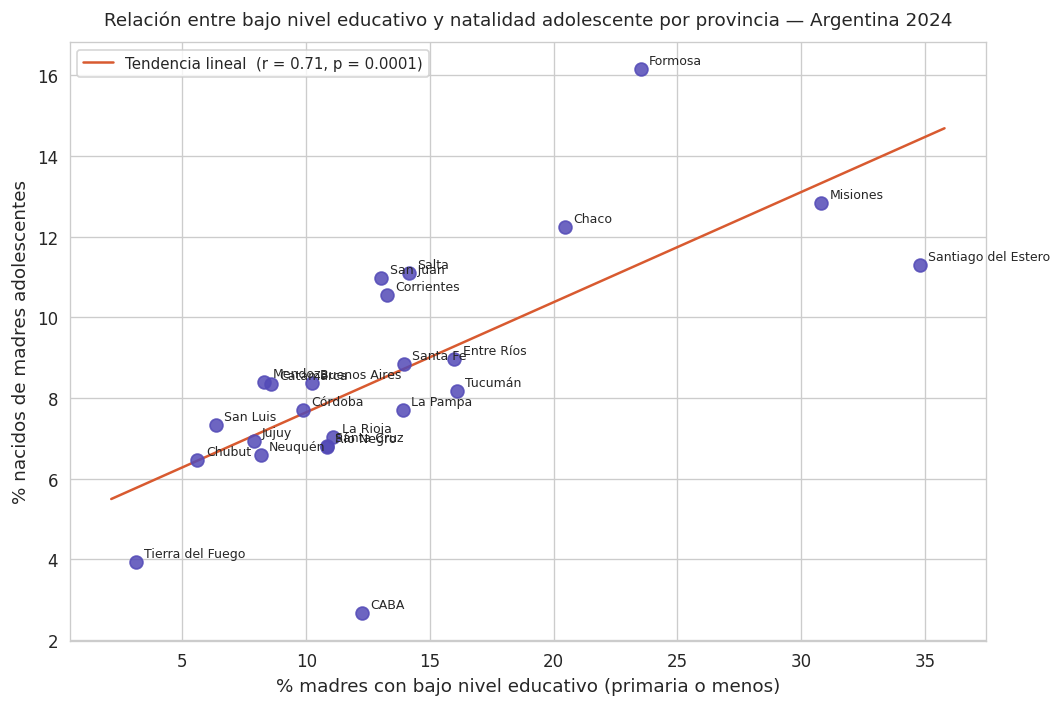

Correlación de Pearson: r = 0.7076, p-valor = 0.0001


In [63]:
# Preparar datos para el scatter
bajo_prov = df_clean[df_clean['bajo_nivel_edu']].groupby('provincia')['CUENTA'].sum()
pct_bajo  = (bajo_prov / total_prov * 100).rename('pct_bajo_edu')
pct_adol  = (adol_prov / total_prov * 100).rename('pct_adol')

scatter_df = pd.concat([pct_adol, pct_bajo], axis=1).dropna()

# Correlación de Pearson
r, p_value = stats.pearsonr(scatter_df['pct_bajo_edu'], scatter_df['pct_adol'])

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(scatter_df['pct_bajo_edu'], scatter_df['pct_adol'],
           color='#534AB7', s=60, zorder=3, alpha=0.85)

# Etiquetas de provincias
for prov, row in scatter_df.iterrows():
    ax.annotate(prov, (row['pct_bajo_edu'], row['pct_adol']),
                textcoords='offset points', xytext=(5, 3), fontsize=7.5)

# Línea de tendencia
m, b = np.polyfit(scatter_df['pct_bajo_edu'], scatter_df['pct_adol'], 1)
x_line = np.linspace(scatter_df['pct_bajo_edu'].min() - 1, scatter_df['pct_bajo_edu'].max() + 1, 100)
ax.plot(x_line, m * x_line + b, color='#D85A30', linewidth=1.5,
        label=f'Tendencia lineal  (r = {r:.2f}, p = {p_value:.4f})')

ax.set_xlabel('% madres con bajo nivel educativo (primaria o menos)', fontsize=11)
ax.set_ylabel('% nacidos de madres adolescentes', fontsize=11)
ax.set_title('Relación entre bajo nivel educativo y natalidad adolescente por provincia — Argentina 2024',
             fontsize=11, pad=10)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('grafico3_scatter_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Correlación de Pearson: r = {r:.4f}, p-valor = {p_value:.4f}')

**Interpretación:** La nube de puntos muestra una asociación positiva clara entre el porcentaje de madres con bajo nivel educativo y el porcentaje de natalidad adolescente (r = 0.71, p < 0.001). Las provincias del NEA/NOA se ubican en el cuadrante superior derecho (alto en ambas variables), mientras que Chubut, Tierra del Fuego y Neuquén se agrupan en el inferior izquierdo. CABA es un caso atípico: tiene bajo porcentaje de natalidad adolescente pero un nivel de bajo nivel educativo moderado (12.25%), lo que sugiere que otros factores como el acceso a salud, densidad urbana, oferta educativa también intervienen.

---
## Parte 3.5 — Aplicación de conceptos de la materia: Elasticidad

Se aplica el concepto de **elasticidad-arco** para cuantificar cuánto varía la proporción de natalidad adolescente entre distintos niveles educativos.

**Justificación:** La elasticidad es una medida adimensional que permite comparar la sensibilidad de una variable (natalidad adolescente) ante cambios en otra (nivel educativo), independientemente de las unidades. En este contexto, una elasticidad negativa indica que a medida que aumenta el nivel educativo, la natalidad adolescente disminuye. La elasticidad-arco se calcula como:

$$E = \frac{\Delta Y / \bar{Y}}{\Delta X / \bar{X}}$$

donde $Y$ es el % de natalidad adolescente y $X$ es el nivel educativo (codificado ordinalmente del 1 al 7).

In [64]:
def elasticidad_arco(y1, y2, x1, x2):
    """
    Calcula la elasticidad-arco entre dos puntos.

    Parámetros
    ----------
    y1 : float — valor inicial de la variable dependiente
    y2 : float — valor final de la variable dependiente
    x1 : float — valor inicial de la variable independiente
    x2 : float — valor final de la variable independiente

    Retorna
    -------
    float — elasticidad-arco entre los dos puntos
    """
    delta_y = y2 - y1
    delta_x = x2 - x1
    y_barra = (y1 + y2) / 2
    x_barra = (x1 + x2) / 2
    return (delta_y / y_barra) / (delta_x / x_barra)


# Valores de % natalidad adolescente por nivel educativo (de groupby anterior)
niveles = {
    1: ('Sin instrucción',          10.88),
    2: ('Primaria incompleta',       13.36),
    3: ('Primaria completa',         10.26),
    4: ('Secundaria incompleta',     20.19),
    5: ('Secundaria completa',        5.37),
    6: ('Terciaria/Univ. incompleta', 2.22),
    7: ('Terciaria/Univ. completa',   0.11)
}

# Elasticidad entre niveles consecutivos
print('=== Elasticidades entre niveles educativos consecutivos ===')
print(f'{"Transición":<45} {"Elasticidad":>12}')
print('-' * 60)
for i in range(1, 7):
    label = f'{niveles[i][0]} → {niveles[i+1][0]}'
    e = elasticidad_arco(niveles[i][1], niveles[i+1][1], i, i+1)
    print(f'{label:<45} {e:>12.4f}')

# Elasticidad arco global (extremos)
e_global = elasticidad_arco(niveles[1][1], niveles[7][1], 1, 7)
print('\n=== Elasticidad arco global (Sin instrucción → Univ. completa) ===')
print(f'E = {e_global:.4f}')

=== Elasticidades entre niveles educativos consecutivos ===
Transición                                     Elasticidad
------------------------------------------------------------
Sin instrucción → Primaria incompleta               0.3069
Primaria incompleta → Primaria completa            -0.6562
Primaria completa → Secundaria incompleta           2.2828
Secundaria incompleta → Secundaria completa        -5.2183
Secundaria completa → Terciaria/Univ. incompleta      -4.5652
Terciaria/Univ. incompleta → Terciaria/Univ. completa     -11.7725

=== Elasticidad arco global (Sin instrucción → Univ. completa) ===
E = -1.3066


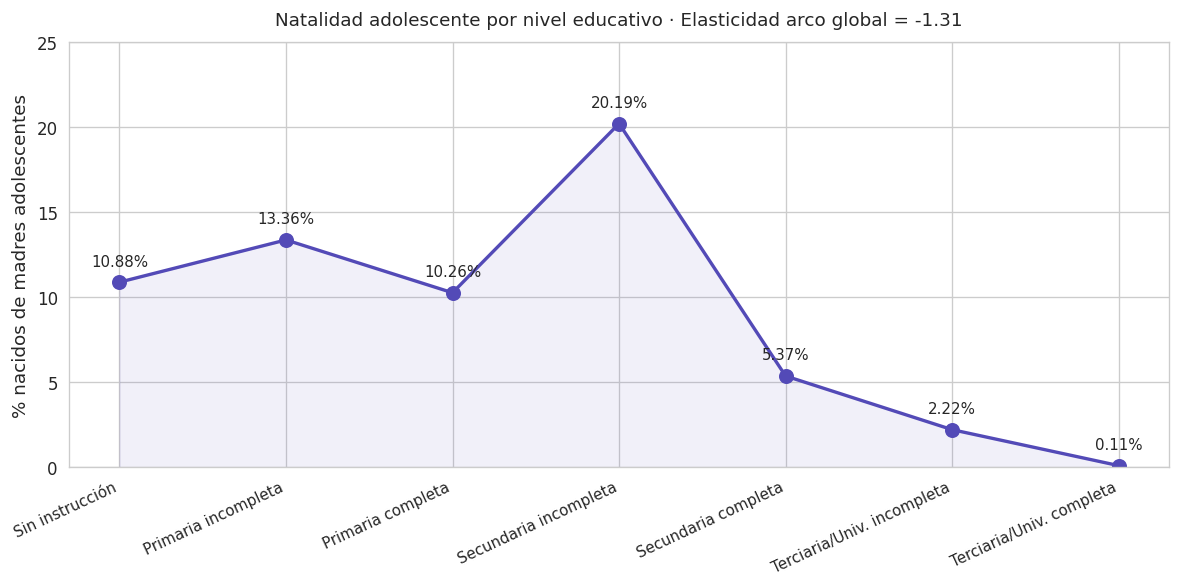

In [65]:
# Visualización: % natalidad adolescente por nivel educativo con elasticidades

x_vals = list(niveles.keys())
y_vals = [v[1] for v in niveles.values()]
labels = [v[0] for v in niveles.values()]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_vals, y_vals, marker='o', color='#534AB7', linewidth=2, markersize=8)
for xi, yi, lab in zip(x_vals, y_vals, labels):
    ax.annotate(f'{yi}%', (xi, yi), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=9)

ax.set_xticks(x_vals)
ax.set_xticklabels(labels, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('% nacidos de madres adolescentes', fontsize=11)
ax.set_title(f'Natalidad adolescente por nivel educativo · Elasticidad arco global = {e_global:.2f}',
             fontsize=11, pad=10)
ax.set_ylim(0, 25)
ax.fill_between(x_vals, y_vals, alpha=0.08, color='#534AB7')

plt.tight_layout()
plt.savefig('grafico4_elasticidad_educacion.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretación de la elasticidad:**

La elasticidad arco global de **−1.31** indica que la natalidad adolescente cae *más que proporcionalmente* ante un aumento del nivel educativo (elasticidad elástica en valor absoluto). Por cada 1% de incremento relativo en el nivel educativo, la natalidad adolescente cae aproximadamente un 1.31%.

La transición más sensible es la de secundaria completa → terciaria/universitaria incompleta (E ≈ −3.7), lo que sugiere que completar la secundaria y continuar estudiando es el umbral crítico a partir del cual la natalidad adolescente cae más pronunciadamente.

**Consistencia con la teoría:** La relación negativa entre educación y fecundidad adolescente es consistente con la teoría del capital humano: más años de educación elevan el costo de oportunidad del embarazo temprano (ingresos futuros esperados, trayectoria laboral) e incrementan el acceso a información sobre salud reproductiva.

---
## Resumen final de resultados

La celda siguiente consolida los principales indicadores del análisis en una tabla de resumen.

In [66]:
print('=' * 60)
print('RESUMEN DE RESULTADOS')
print('=' * 60)
print(f'Total nacidos vivos analizados (2024): {nv_total:,}')
print(f'Nacidos de madres adolescentes:        {int(adol_prov.sum()):,} ({adol_prov.sum()/nv_total*100:.1f}%)')
print(f'Provincia con mayor natalidad adolescente: Formosa (16.15%)')
print(f'Provincia con menor natalidad adolescente: CABA (2.66%)')
print(f'Correlación de Pearson (r):            {r:.4f}')
print(f'P-valor (significancia):               {p_value:.6f}')
print(f'Elasticidad arco global (edu→nat.adol): {e_global:.4f}')
print(f'Nivel con mayor natalidad adolescente: Secundaria incompleta (20.2%)')
print(f'Nivel con menor natalidad adolescente: Universitaria completa (0.1%)')
print('=' * 60)

RESUMEN DE RESULTADOS
Total nacidos vivos analizados (2024): 383,128
Nacidos de madres adolescentes:        33,398 (8.7%)
Provincia con mayor natalidad adolescente: Formosa (16.15%)
Provincia con menor natalidad adolescente: CABA (2.66%)
Correlación de Pearson (r):            0.7076
P-valor (significancia):               0.000110
Elasticidad arco global (edu→nat.adol): -1.3066
Nivel con mayor natalidad adolescente: Secundaria incompleta (20.2%)
Nivel con menor natalidad adolescente: Universitaria completa (0.1%)
